Explporacion y Extraccion de datos

PRIMERO DEBE DESCARGAR EL CSV "US_Accidents_March23.csv" Y PONERLO AL LADO DE "ETL.ipynb"

In [12]:
# ---------------------------------------------------------
# IMPORTAR LIBRERÍAS
# ---------------------------------------------------------
# Se importan las librerías necesarias para manipulación
# de datos, visualización y análisis inicial.
# ---------------------------------------------------------
%pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# configuración de gráficos
sns.set(style="whitegrid")

print("Librerías cargadas correctamente")

Note: you may need to restart the kernel to use updated packages.
Librerías cargadas correctamente



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# ---------------------------------------------------------
# CARGAR EL DATASET
# ---------------------------------------------------------
# Se carga el dataset desde el archivo CSV.
# En datasets grandes puede tardar un poco.
# ---------------------------------------------------------

df = pd.read_csv("US_Accidents_March23.csv")

print("Dataset cargado correctamente")
print("Dimensiones del dataset (filas, columnas):")
print(df.shape)

Dataset cargado correctamente
Dimensiones del dataset (filas, columnas):
(7728394, 46)


In [14]:
# ---------------------------------------------------------
# MOSTRAR LAS PRIMERAS FILAS
# ---------------------------------------------------------
# Esto permite ver la estructura del dataset y algunos
# ejemplos de registros.
# ---------------------------------------------------------

print("\nPrimeras 5 filas del dataset:")
print(df.head())


Primeras 5 filas del dataset:
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  F

In [15]:
# ---------------------------------------------------------
# INFORMACIÓN GENERAL DEL DATASET
# ---------------------------------------------------------
# Muestra tipos de datos, columnas y valores no nulos.
# Muy útil para entender la estructura del dataset.
# ---------------------------------------------------------

print("\nInformación general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)       

In [16]:
# ---------------------------------------------------------
# CANTIDAD DE DATOS POR COLUMNA
# ---------------------------------------------------------
# Se cuenta cuántos valores no nulos hay en cada columna.
# Esto permite detectar columnas incompletas.
# ---------------------------------------------------------

print("\nCantidad de valores no nulos por columna:")
print(df.count())


Cantidad de valores no nulos por columna:
ID                       7728394
Source                   7728394
Severity                 7728394
Start_Time               7728394
End_Time                 7728394
Start_Lat                7728394
Start_Lng                7728394
End_Lat                  4325632
End_Lng                  4325632
Distance(mi)             7728394
Description              7728389
Street                   7717525
City                     7728141
County                   7728394
State                    7728394
Zipcode                  7726479
Country                  7728394
Timezone                 7720586
Airport_Code             7705759
Weather_Timestamp        7608166
Temperature(F)           7564541
Wind_Chill(F)            5729375
Humidity(%)              7554250
Pressure(in)             7587715
Visibility(mi)           7551296
Wind_Direction           7553188
Wind_Speed(mph)          7157161
Precipitation(in)        5524808
Weather_Condition        7554935


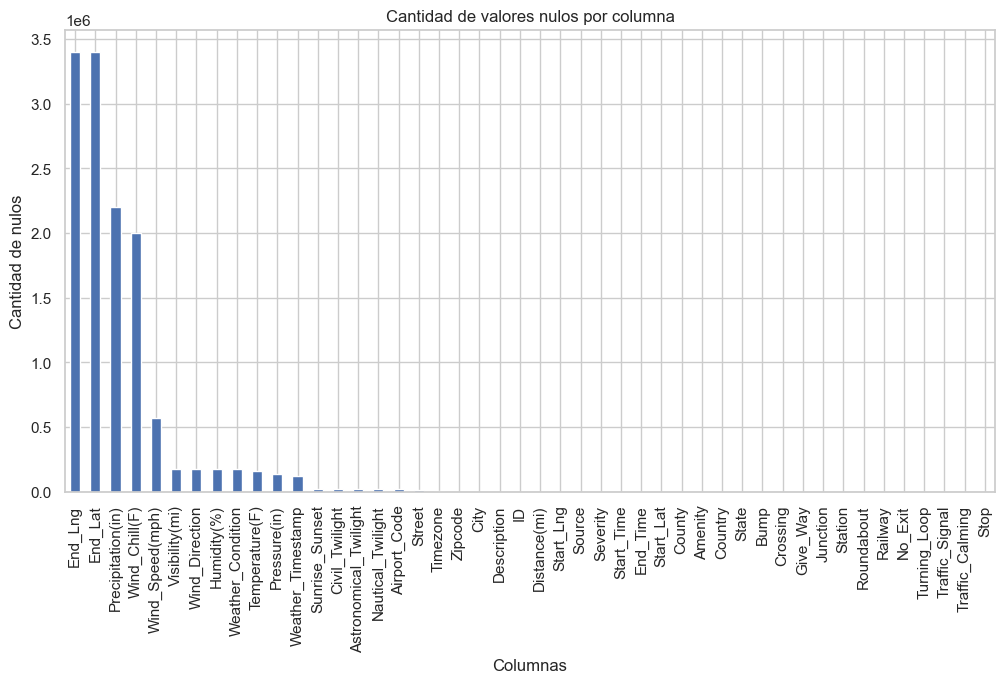

In [17]:
# ---------------------------------------------------------
# GRÁFICO DE VALORES NULOS
# ---------------------------------------------------------
# Visualiza los valores nulos por columna.
# Esto ayuda a identificar columnas con muchos datos faltantes.
# ---------------------------------------------------------

null_values = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
null_values.plot(kind='bar')

plt.title("Cantidad de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("Cantidad de nulos")

plt.xticks(rotation=90)
plt.show()

In [18]:
# ---------------------------------------------------------
# DETECTAR VALORES NULOS
# ---------------------------------------------------------
# Se calcula cuántos valores nulos hay en cada columna.
# ---------------------------------------------------------

print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())


Cantidad de valores nulos por columna:
ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Ame


Distribución de Severity:
Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64


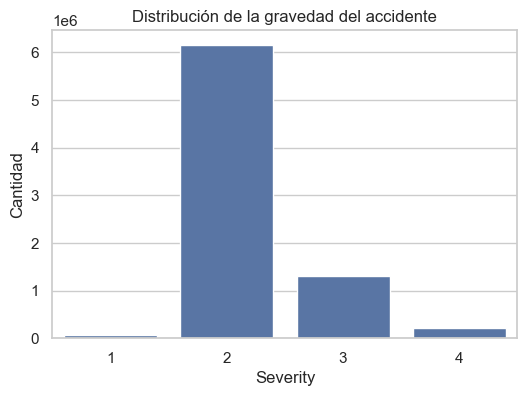

In [19]:
# ---------------------------------------------------------
# DISTRIBUCIÓN DE LA GRAVEDAD DEL ACCIDENTE
# ---------------------------------------------------------
# Analiza cómo se distribuye la variable Severity.
# ---------------------------------------------------------

print("\nDistribución de Severity:")
print(df['Severity'].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(x='Severity', data=df)

plt.title("Distribución de la gravedad del accidente")
plt.xlabel("Severity")
plt.ylabel("Cantidad")

plt.show()


Top 10 estados con más accidentes:
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
Name: count, dtype: int64


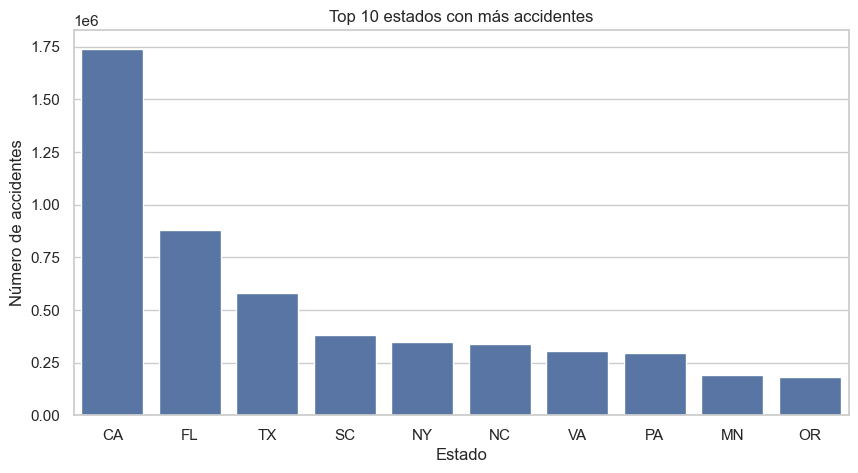

In [20]:
# ---------------------------------------------------------
# ACCIDENTES POR ESTADO
# ---------------------------------------------------------
# Permite identificar los estados con mayor cantidad
# de accidentes.
# ---------------------------------------------------------

top_states = df['State'].value_counts().head(10)

print("\nTop 10 estados con más accidentes:")
print(top_states)

plt.figure(figsize=(10,5))

sns.barplot(x=top_states.index, y=top_states.values)

plt.title("Top 10 estados con más accidentes")
plt.xlabel("Estado")
plt.ylabel("Número de accidentes")

plt.show()

Analisis y transformacion de datos

In [21]:
# ---------------------------------------------------------
# ANALIZAR CONSISTENCIA EN LA COLUMNA CITY
# ---------------------------------------------------------
# Este paso permite detectar si existen variaciones del mismo
# nombre de ciudad debido a mayúsculas/minúsculas.
# Por ejemplo: "miami", "Miami", "MIAMI".
# ---------------------------------------------------------

print("Número total de valores únicos en City:")
unicas=df['City'].nunique()
print(unicas)

print("\nEjemplos de ciudades:")
print(df['City'].value_counts().head(20))

# Normalizamos temporalmente para detectar duplicados por formato
city_normalized = df['City'].str.lower().str.strip()

print("\nNúmero de ciudades únicas después de normalizar:")
print(city_normalized.nunique())

# Comparación
print("\nPosibles inconsistencias detectadas:")
df.groupby(city_normalized)['City'].nunique().sort_values(ascending=False).head(10)

Número total de valores únicos en City:
13678

Ejemplos de ciudades:
City
Miami            186917
Houston          169609
Los Angeles      156491
Charlotte        138652
Dallas           130939
Orlando          109733
Austin            97359
Raleigh           86079
Nashville         72930
Baton Rouge       71588
Atlanta           68186
Sacramento        66264
San Diego         55504
Phoenix           53974
Minneapolis       51488
Richmond          48845
Oklahoma City     46092
Jacksonville      42447
Tucson            39304
Columbia          38178
Name: count, dtype: int64

Número de ciudades únicas después de normalizar:
13622

Posibles inconsistencias detectadas:


City
cardiff by the sea    3
forks of salmon       2
croton on hudson      2
lagrange              2
la place              2
hastings on hudson    2
bayou la batre        2
king of prussia       2
bird in hand          2
debary                2
Name: City, dtype: int64

Transformar ciudad

In [22]:
df['City'] = df['City'].str.lower().str.strip()
print("Número total de valores únicos en City:")
unicas_norm=df['City'].nunique()
print(unicas_norm)
print("se corrigió", unicas-unicas_norm, "ciudades")

Número total de valores únicos en City:
13622
se corrigió 56 ciudades


In [23]:
# ---------------------------------------------------------
# ANALIZAR CONSISTENCIA EN STREET
# ---------------------------------------------------------
# Las calles pueden tener inconsistencias en abreviaciones,
# mayúsculas o espacios.
# ---------------------------------------------------------

print("Número total de calles únicas:")
unicasS = df['Street'].nunique()
print(unicasS)

print("\nCalles más frecuentes:")
print(df['Street'].value_counts().head(20))

street_normalized = df['Street'].str.lower().str.strip()

print("\nNúmero de calles únicas después de normalizar:")
print(street_normalized.nunique())

df.groupby(street_normalized)['Street'] \
  .agg(['nunique', lambda x: list(x.unique())]) \
  .rename(columns={'<lambda_0>': 'original_values'}) \
  .sort_values(by='nunique', ascending=False) \
  .head(10)
#print("")
#df.groupby(street_normalized)['Street'].nunique().sort_values(ascending=False).head(10)


Número total de calles únicas:
336306

Calles más frecuentes:
Street
I-95 N      78430
I-95 S      74528
I-5 N       71968
I-10 E      55572
I-10 W      53725
I-5 S       51781
I-80 W      39662
I-80 E      36113
I-405 N     32364
I-75 N      28166
I-75 S      27546
I-90 E      26426
I-15 N      24470
I-94 W      24003
I-90 W      23279
US-101 N    20041
I-95        20028
I-94 E      19940
I-70 E      19697
I-15 S      19230
Name: count, dtype: int64

Número de calles únicas después de normalizar:
249140


,nunique,original_values
Street,,
us highway 65,4,"[US Highway 65, US Highway 65, Us Highway 65..."
state route 51,4,"[State Route 51, State route 51, State Route ..."
alameda de las pulgas,4,"[Alameda de Las Pulgas, Alameda de las Pulgas,..."
1st st,4,"[1st St, 1St St, 1st St, 1St St]"
s il route 59,4,"[S Il Route 59, S IL Route 59, S IL Route 59,..."
spring valley dr,4,"[Spring Valley Dr, Spring valley Dr, Spring v..."
smu blvd,4,"[Smu Blvd, Smu Blvd, SMU Blvd, SMU Blvd]"
camino la costa,4,"[Camino la Costa, Camino la Costa, Camino La ..."
transit dr,4,"[TRANSIT Dr, Transit Dr, TRANSIT Dr, Transit..."


voy aqui, falta normalizar street

In [24]:
df['Street'] = df['Street'].str.lower().str.strip()
unicasS_norm = df['Street'].nunique()
(print("se corrigió", unicasS-unicasS_norm, "calles"))

se corrigió 87166 calles


In [25]:
# ---------------------------------------------------------
# ANALIZAR CONSISTENCIA EN COUNTY
# ---------------------------------------------------------
# Permite detectar inconsistencias en nombres de condados
# debidas a formato de texto.
# ---------------------------------------------------------

print("Número total de counties únicos:")
unicasCounty = df['County'].nunique()
print(unicasCounty)

print("\nCounties más frecuentes:")
print(df['County'].value_counts().head(20))

county_normalized = df['County'].str.lower().str.strip()

print("\nCounties únicos después de normalizar:")
print(county_normalized.nunique())

df.groupby(county_normalized)['County'] \
  .agg(['nunique', lambda x: list(x.unique())]) \
  .rename(columns={'<lambda_0>': 'original_values'}) \
  .sort_values(by='nunique', ascending=False) \
  .head(10)


Número total de counties únicos:
1871

Counties más frecuentes:
County
Los Angeles         526851
Miami-Dade          251601
Orange              241275
Harris              181196
Dallas              157024
Mecklenburg         147265
Montgomery          136788
Wake                117890
San Bernardino      109631
Travis              107881
Maricopa            106737
San Diego           104165
Alameda              98553
Davidson             96580
Sacramento           95377
Riverside            88248
East Baton Rouge     75260
Santa Clara          70482
Cook                 65599
Marion               59498
Name: count, dtype: int64

Counties únicos después de normalizar:
1847


,nunique,original_values
County,,
dekalb,2,"[DeKalb, Dekalb]"
desoto,2,"[DeSoto, Desoto]"
lagrange,2,"[LaGrange, Lagrange]"
isle of wight,2,"[Isle of Wight, Isle Of Wight]"
dewitt,2,"[DeWitt, Dewitt]"
fond du lac,2,"[Fond du Lac, Fond Du Lac]"
district of columbia,2,"[District of Columbia, District Of Columbia]"
dupage,2,"[Dupage, DuPage]"
laporte,2,"[Laporte, LaPorte]"


In [26]:
df['County'] = df['County'].str.lower().str.strip()
unicasCounty_norm = df['County'].nunique()
(print("se corrigió", unicasCounty-unicasCounty_norm, "County"))

se corrigió 24 County


In [27]:
# ---------------------------------------------------------
# ANALIZAR CONSISTENCIA EN STATE
# ---------------------------------------------------------
# Los estados deberían tener códigos estándar de dos letras.
# ---------------------------------------------------------

print("Estados únicos:")

print("Número total de states únicos:")
unicasState = df['State'].nunique()
print(unicasState)

print("\nStates más frecuentes:")
print(df['State'].value_counts().head(20))

county_normalized = df['State'].str.lower().str.strip()

print("\nStates únicos después de normalizar:")
print(county_normalized.nunique())

df.groupby(county_normalized)['State'] \
  .agg(['nunique', lambda x: list(x.unique())]) \
  .rename(columns={'<lambda_0>': 'original_values'}) \
  .sort_values(by='nunique', ascending=False) \
  .head(10)

Estados únicos:
Número total de states únicos:
49

States más frecuentes:
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
AZ     170609
GA     169234
IL     168958
TN     167388
MI     162191
LA     149701
NJ     140719
MD     140417
OH     118115
WA     108221
Name: count, dtype: int64

States únicos después de normalizar:
49


,nunique,original_values
State,,
al,1,[AL]
ar,1,[AR]
az,1,[AZ]
ca,1,[CA]
co,1,[CO]
ct,1,[CT]
dc,1,[DC]
de,1,[DE]
fl,1,[FL]


Descripción estadística de Visibility:
count    7.551296e+06
mean     9.090376e+00
std      2.688316e+00
min      0.000000e+00
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      1.400000e+02
Name: Visibility(mi), dtype: float64

Valores únicos de visibilidad:
92


<Axes: title={'center': 'Distribución de visibilidad'}, ylabel='Frequency'>

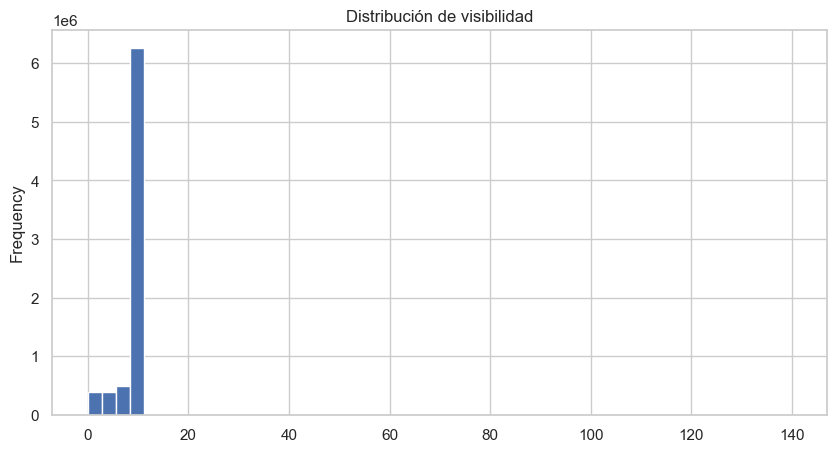

In [28]:
# ---------------------------------------------------------
# ANALIZAR CONSISTENCIA EN VISIBILITY
# ---------------------------------------------------------
# Se revisa la distribución para detectar valores extremos
# o posibles errores de registro.
# ---------------------------------------------------------

print("Descripción estadística de Visibility:")
print(df['Visibility(mi)'].describe())

print("\nValores únicos de visibilidad:")
print(df['Visibility(mi)'].nunique())

# Histograma
df['Visibility(mi)'].plot(kind='hist', bins=50, figsize=(10,5), title="Distribución de visibilidad")

Número de condiciones climáticas únicas:
144

Condiciones climáticas más frecuentes:
Weather_Condition
Fair                       2560802
Mostly Cloudy              1016195
Cloudy                      817082
Clear                       808743
Partly Cloudy               698972
Overcast                    382866
Light Rain                  352957
Scattered Clouds            204829
Light Snow                  128680
Fog                          99238
Rain                         84331
Haze                         76223
Fair / Windy                 35671
Heavy Rain                   32309
Light Drizzle                22684
Thunder in the Vicinity      17611
Cloudy / Windy               17035
T-Storm                      16810
Mostly Cloudy / Windy        16508
Snow                         15537
Name: count, dtype: int64

Condiciones únicas después de normalizar:
144


<Axes: title={'center': 'Condiciones climáticas más comunes'}, xlabel='Weather_Condition'>

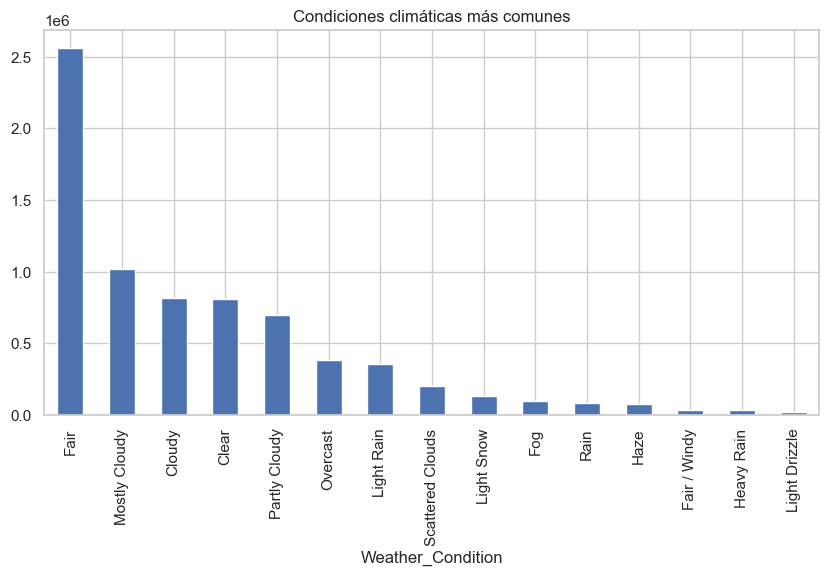

In [29]:
# ---------------------------------------------------------
# ANALIZAR CONSISTENCIA EN WEATHER_CONDITION
# ---------------------------------------------------------
# Se busca detectar variaciones en las condiciones climáticas
# por formato o diferencias de escritura.
# ---------------------------------------------------------

print("Número de condiciones climáticas únicas:")
print(df['Weather_Condition'].nunique())

print("\nCondiciones climáticas más frecuentes:")
print(df['Weather_Condition'].value_counts().head(20))

weather_normalized = df['Weather_Condition'].str.lower().str.strip()

print("\nCondiciones únicas después de normalizar:")
print(weather_normalized.nunique())

# Gráfico
df['Weather_Condition'].value_counts().head(15).plot(kind='bar', figsize=(10,5), title="Condiciones climáticas más comunes")

In [30]:
unique_weather = df['Weather_Condition'].dropna().unique()

for w in sorted(unique_weather):
    print(w)

Blowing Dust
Blowing Dust / Windy
Blowing Sand
Blowing Snow
Blowing Snow / Windy
Blowing Snow Nearby
Clear
Cloudy
Cloudy / Windy
Drifting Snow
Drifting Snow / Windy
Drizzle
Drizzle / Windy
Drizzle and Fog
Dust Whirls
Duststorm
Fair
Fair / Windy
Fog
Fog / Windy
Freezing Drizzle
Freezing Rain
Freezing Rain / Windy
Funnel Cloud
Hail
Haze
Haze / Windy
Heavy Blowing Snow
Heavy Drizzle
Heavy Freezing Drizzle
Heavy Freezing Rain
Heavy Freezing Rain / Windy
Heavy Ice Pellets
Heavy Rain
Heavy Rain / Windy
Heavy Rain Shower
Heavy Rain Shower / Windy
Heavy Rain Showers
Heavy Sleet
Heavy Sleet / Windy
Heavy Sleet and Thunder
Heavy Smoke
Heavy Snow
Heavy Snow / Windy
Heavy Snow with Thunder
Heavy T-Storm
Heavy T-Storm / Windy
Heavy Thunderstorms and Rain
Heavy Thunderstorms and Snow
Heavy Thunderstorms with Small Hail
Ice Pellets
Light Blowing Snow
Light Drizzle
Light Drizzle / Windy
Light Fog
Light Freezing Drizzle
Light Freezing Fog
Light Freezing Rain
Light Freezing Rain / Windy
Light Hail
Light

In [31]:
# ---------------------------------------------------------
# NORMALIZAR TEXTO
# ---------------------------------------------------------
# Convertimos Weather_Condition a minúsculas y quitamos espacios
# ---------------------------------------------------------
df['weather_clean'] = df['Weather_Condition'].str.lower().str.strip()


# ---------------------------------------------------------
# DETECTAR SI HAY VIENTO
# ---------------------------------------------------------
# En el dataset el viento aparece como "/ Windy"
# Ejemplo: "Rain / Windy"
# ---------------------------------------------------------
df['is_windy'] = df['Weather_Condition'].str.contains('/ Windy')

# Mantener NaN si el clima es NaN
df.loc[df['Weather_Condition'].isna(), 'is_windy'] = None

# Eliminamos " / windy" del texto
df['weather_clean'] = df['weather_clean'].str.replace(' / windy', '', regex=False)


# ---------------------------------------------------------
# EXTRAER INTENSIDAD DEL CLIMA
# ---------------------------------------------------------
# Detecta si el clima es light, heavy o normal
# ---------------------------------------------------------
def extract_intensity(text):

    if pd.isna(text):
        return None

    if "light" in text:
        return "light"

    if "heavy" in text:
        return "heavy"

    return "normal"


df['intensity'] = df['weather_clean'].apply(extract_intensity)

# Eliminamos light y heavy del texto
df['weather_clean'] = df['weather_clean'].str.replace(
    r"\blight\b|\bheavy\b", "", regex=True
).str.strip()


# ---------------------------------------------------------
# UNIFICAR TERMINOS SIMILARES
# ---------------------------------------------------------
# Algunas condiciones tienen nombres distintos pero significan lo mismo
# ---------------------------------------------------------
def unify_terms(text):

    if pd.isna(text):
        return text

    text = text.replace("t-storm", "thunderstorm")
    text = text.replace("tstorm", "thunderstorm")
    text = text.replace("showers", "shower")
    text = text.replace("wintry mix", "sleet")
    text = text.replace("ice pellets", "sleet")

    return text


df['weather_clean'] = df['weather_clean'].apply(unify_terms)


# ---------------------------------------------------------
# CATEGORIZAR TIPO DE CLIMA
# ---------------------------------------------------------
# Agrupamos las condiciones climáticas en categorías principales
# ---------------------------------------------------------
def categorize_weather(text):

    if pd.isna(text) or text == "":
        return None

    if "snow" in text:
        return "snow"
    
    elif "sleet" in text:
        return "sleet"
    
    elif "rain" in text or "drizzle" in text:
        return "rain"

    elif "fog" in text or "mist" in text:
        return "fog"

    elif "cloud" in text or "overcast" in text:
        return "cloudy"

    elif "clear" in text or "fair" in text:
        return "clear"

    elif "hail" in text or "ice" in text:
        return "hail"

    elif "dust" in text or "sand" in text or "smoke" in text:
        return "dust/smoke"

    elif "tornado" in text or "funnel cloud" in text or "squalls" in text:
        return "extreme"
    
    if "thunder" in text:
        return "thunderstorm"
    
    else:
        return "other"


df['weather_type'] = df['weather_clean'].apply(categorize_weather)


# ---------------------------------------------------------
# ELIMINAR COLUMNAS TEMPORALES
# ---------------------------------------------------------
# Quitamos la columna original y la auxiliar usada para limpieza
# ---------------------------------------------------------
df.drop(columns=['Weather_Condition', 'weather_clean'], inplace=True)


# ---------------------------------------------------------
# MOSTRAR RESULTADO
# ---------------------------------------------------------
print("\nEjemplo de transformación:")
print(df[['weather_type','intensity','is_windy']].head(20))


# ---------------------------------------------------------
# DISTRIBUCIÓN DE VARIABLES
# ---------------------------------------------------------
print("\nDistribución de tipos de clima:")
print(df['weather_type'].value_counts())

print("\nDistribución de intensidad:")
print(df['intensity'].value_counts())

print("\nDistribución de viento:")
print(df['is_windy'].value_counts())


# ---------------------------------------------------------
# VERIFICAR NULOS
# ---------------------------------------------------------
print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())


Ejemplo de transformación:
   weather_type intensity is_windy
0          rain     light    False
1          rain     light    False
2        cloudy    normal    False
3        cloudy    normal    False
4        cloudy    normal    False
5          rain     light    False
6        cloudy    normal    False
7        cloudy    normal    False
8        cloudy    normal    False
9          rain     light    False
10         rain    normal    False
11         rain     light    False
12       cloudy    normal    False
13       cloudy    normal    False
14         rain     light    False
15       cloudy    normal    False
16       cloudy    normal    False
17       cloudy    normal    False
18       cloudy    normal    False
19       cloudy    normal    False

Distribución de tipos de clima:
weather_type
clear           3405216
cloudy          3163750
rain             538861
snow             160802
fog              111807
other             82616
thunderstorm      65206
dust/smoke        13511


Distribución de tipos de clima:
weather_type
clear           3405216
cloudy          3163750
rain             538861
None             173459
snow             160802
fog              111807
other             82616
thunderstorm      65206
dust/smoke        13511
sleet             12925
hail                140
extreme             101
Name: count, dtype: int64


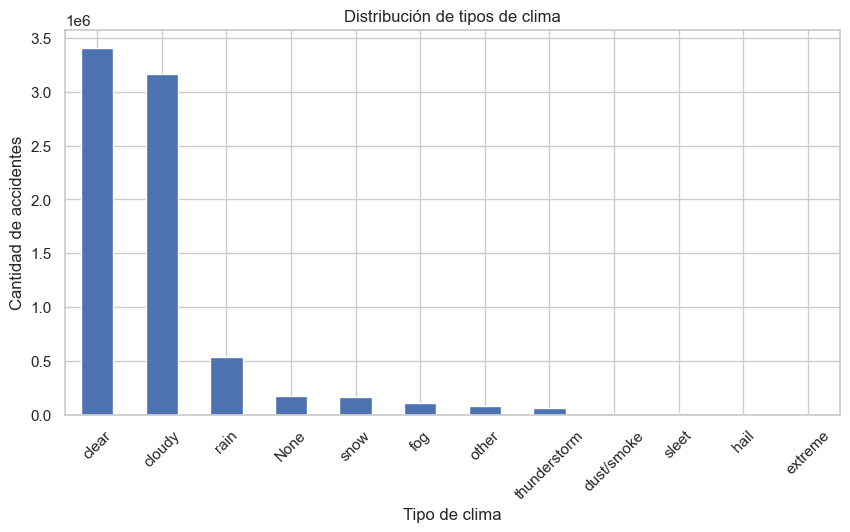


Distribución de intensidad:
intensity
normal    6956378
light      545023
None       173459
heavy       53534
Name: count, dtype: int64


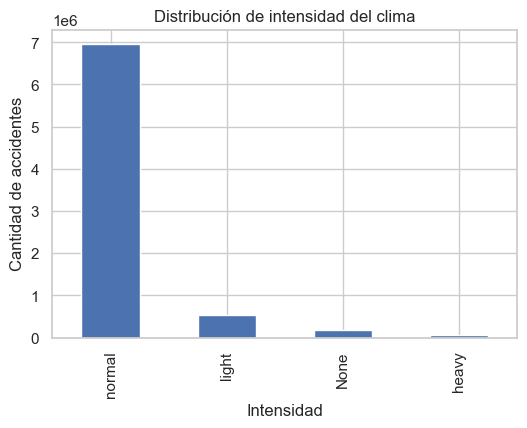


Distribución de viento:
is_windy
False    7447505
None      173459
True      107430
Name: count, dtype: int64


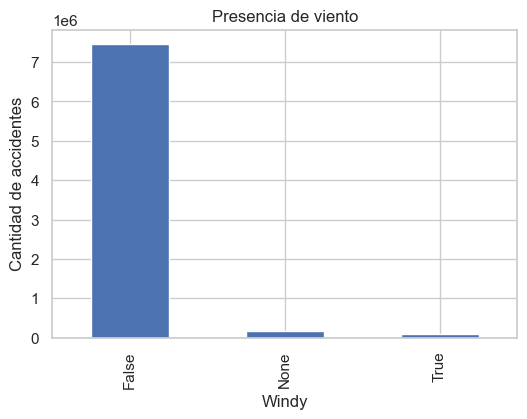

In [32]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# GRAFICO 1: DISTRIBUCION DE TIPOS DE CLIMA
# ---------------------------------------------------------
print("\nDistribución de tipos de clima:")
weather_counts = df['weather_type'].value_counts(dropna=False)
print(weather_counts)

plt.figure(figsize=(10,5))
weather_counts.plot(kind='bar')
plt.title("Distribución de tipos de clima")
plt.xlabel("Tipo de clima")
plt.ylabel("Cantidad de accidentes")
plt.xticks(rotation=45)
plt.show()


# ---------------------------------------------------------
# GRAFICO 2: DISTRIBUCION DE INTENSIDAD DEL CLIMA
# ---------------------------------------------------------
print("\nDistribución de intensidad:")
intensity_counts = df['intensity'].value_counts(dropna=False)
print(intensity_counts)

plt.figure(figsize=(6,4))
intensity_counts.plot(kind='bar')
plt.title("Distribución de intensidad del clima")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de accidentes")
plt.show()


# ---------------------------------------------------------
# GRAFICO 3: DISTRIBUCION DE VIENTO
# ---------------------------------------------------------
print("\nDistribución de viento:")
wind_counts = df['is_windy'].value_counts(dropna=False)
print(wind_counts)

plt.figure(figsize=(6,4))
wind_counts.plot(kind='bar')
plt.title("Presencia de viento")
plt.xlabel("Windy")
plt.ylabel("Cantidad de accidentes")
plt.show()

In [33]:
# ---------------------------------------------------------
# VERIFICAR FORMATO DE START_TIME
# ---------------------------------------------------------
# Se revisa el tipo de dato de Start_Time para confirmar
# si está en formato de fecha o como texto.
# ---------------------------------------------------------

print("\nTipo de dato de Start_Time:")
print(df['Start_Time'].dtype)

print("\nEjemplos de valores de Start_Time:")
print(df['Start_Time'].head())


Tipo de dato de Start_Time:
object

Ejemplos de valores de Start_Time:
0    2016-02-08 05:46:00
1    2016-02-08 06:07:59
2    2016-02-08 06:49:27
3    2016-02-08 07:23:34
4    2016-02-08 07:39:07
Name: Start_Time, dtype: object


In [34]:
print("\nInformación de la columna temperatura:")
print(df['Temperature(F)'].describe())


Información de la columna temperatura:
count    7.564541e+06
mean     6.166329e+01
std      1.901365e+01
min     -8.900000e+01
25%      4.900000e+01
50%      6.400000e+01
75%      7.600000e+01
max      2.070000e+02
Name: Temperature(F), dtype: float64


In [35]:
# ---------------------------------------------------------
# CONVERTIR TEMPERATURA DE FAHRENHEIT A CELSIUS
# ---------------------------------------------------------
# Formula: C = (F - 32) * 5/9
# ---------------------------------------------------------

df['Temperature(C)'] = (df['Temperature(F)'] - 32) * 5/9


# ---------------------------------------------------------
# MOSTRAR EJEMPLO DE LA CONVERSION
# ---------------------------------------------------------
print("\nEjemplo de conversión de temperatura:")
print(df[['Temperature(F)', 'Temperature(C)']].head(10))


# ---------------------------------------------------------
# ELIMINAR LA COLUMNA ORIGINAL EN FAHRENHEIT 
# ---------------------------------------------------------
df.drop(columns=['Temperature(F)'], inplace=True)


# ---------------------------------------------------------
# RENOMBRAR LA COLUMNA A Temperature
# ---------------------------------------------------------
df.rename(columns={'Temperature(C)': 'Temperature'}, inplace=True)


# ---------------------------------------------------------
# VERIFICAR RESULTADO
# ---------------------------------------------------------
print("\nInformación de la columna temperatura:")
print(df['Temperature'].describe())


Ejemplo de conversión de temperatura:
   Temperature(F)  Temperature(C)
0            36.9        2.722222
1            37.9        3.277778
2            36.0        2.222222
3            35.1        1.722222
4            36.0        2.222222
5            37.9        3.277778
6            34.0        1.111111
7            34.0        1.111111
8            33.3        0.722222
9            37.4        3.000000

Información de la columna temperatura:
count    7.564541e+06
mean     1.647960e+01
std      1.056314e+01
min     -6.722222e+01
25%      9.444444e+00
50%      1.777778e+01
75%      2.444444e+01
max      9.722222e+01
Name: Temperature, dtype: float64


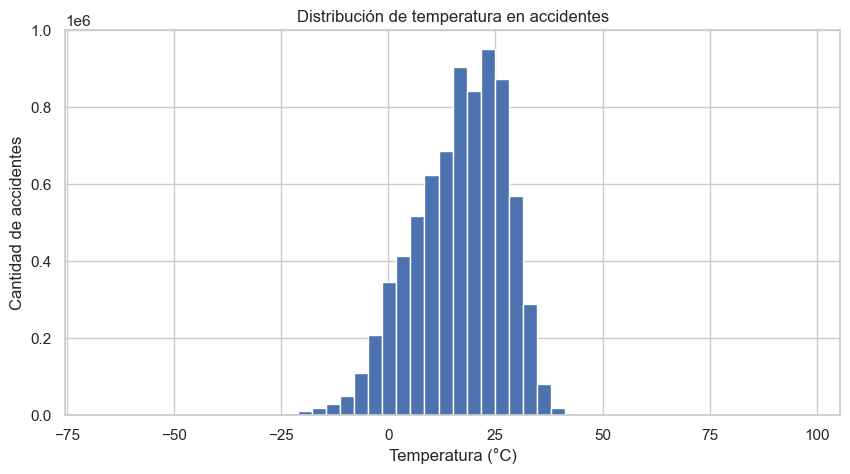


Estadísticas de temperatura:
count    7.564541e+06
mean     1.647960e+01
std      1.056314e+01
min     -6.722222e+01
25%      9.444444e+00
50%      1.777778e+01
75%      2.444444e+01
max      9.722222e+01
Name: Temperature, dtype: float64


In [36]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# GRAFICO: DISTRIBUCION DE LA TEMPERATURA
# ---------------------------------------------------------
# Un histograma muestra cómo se distribuyen los valores
# de temperatura en el dataset
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

plt.hist(df['Temperature'], bins=50)

plt.title("Distribución de temperatura en accidentes")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Cantidad de accidentes")

plt.show()


# ---------------------------------------------------------
# INFORMACION ESTADISTICA DE LA TEMPERATURA
# ---------------------------------------------------------
print("\nEstadísticas de temperatura:")
print(df['Temperature'].describe())

In [37]:
# ---------------------------------------------------------
# CONVERTIR START_TIME A FORMATO DATETIME
# ---------------------------------------------------------
# Esto es necesario para poder analizar fechas y horas.
# ---------------------------------------------------------
# ---------------------------------------------------------
# DETECTAR VALORES QUE NO SE PUEDEN CONVERTIR A FECHA
# ---------------------------------------------------------
# Se deteto que algunas fechas tienen milisegundos, por lo que se debe primero quitar eso
#luego se convierte a datetime
# ---------------------------------------------------------
df['Start_Time'] = df['Start_Time'].str.split('.').str[0]

df['Start_Time'] = pd.to_datetime(df['Start_Time'])

mask = pd.to_datetime(df['Start_Time'], errors='coerce').isna()

print("Cantidad de fechas problemáticas:")
print(mask.sum())

print("\nEjemplos de fechas problemáticas:")
print(df.loc[mask, 'Start_Time'].head(20))

print("\nTipo de dato de Start_Time:")
print(df['Start_Time'].dtype)

print("\nEjemplos de valores de Start_Time:")
print(df['Start_Time'].head())

Cantidad de fechas problemáticas:
0

Ejemplos de fechas problemáticas:
Series([], Name: Start_Time, dtype: datetime64[ns])

Tipo de dato de Start_Time:
datetime64[ns]

Ejemplos de valores de Start_Time:
0   2016-02-08 05:46:00
1   2016-02-08 06:07:59
2   2016-02-08 06:49:27
3   2016-02-08 07:23:34
4   2016-02-08 07:39:07
Name: Start_Time, dtype: datetime64[ns]


In [38]:
print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())


Cantidad de valores nulos por columna:
ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Amenity                        0
Bump                           0
Cro

In [39]:
print(df['Start_Time'].head(20))
print(df['Start_Time'].sample(20))

0    2016-02-08 05:46:00
1    2016-02-08 06:07:59
2    2016-02-08 06:49:27
3    2016-02-08 07:23:34
4    2016-02-08 07:39:07
5    2016-02-08 07:44:26
6    2016-02-08 07:59:35
7    2016-02-08 07:59:58
8    2016-02-08 08:00:40
9    2016-02-08 08:10:04
10   2016-02-08 08:14:42
11   2016-02-08 08:21:27
12   2016-02-08 08:36:34
13   2016-02-08 08:37:07
14   2016-02-08 08:39:43
15   2016-02-08 08:43:20
16   2016-02-08 08:53:17
17   2016-02-08 09:24:37
18   2016-02-08 09:25:17
19   2016-02-08 09:35:35
Name: Start_Time, dtype: datetime64[ns]
666022    2022-03-16 07:20:22
969307    2021-07-05 20:07:28
4215976   2023-01-20 16:20:00
1627392   2020-02-08 08:25:49
2786679   2018-05-01 08:44:17
4201311   2022-12-09 02:53:00
2528381   2018-10-23 16:33:38
2427685   2018-11-06 09:42:58
872587    2021-09-27 09:30:56
561240    2022-07-15 16:59:47
6157833   2021-08-27 06:24:00
1637177   2020-02-13 10:56:04
5471368   2021-05-06 12:54:37
1119135   2021-03-06 01:08:57
7164597   2020-01-08 23:12:42
2923100   

limpieza de datos atipicos y eliminacion de columnas que no son de nuestro interes

In [40]:
print(df.describe())

           Severity                     Start_Time     Start_Lat  \
count  7.728394e+06                        7728394  7.728394e+06   
mean   2.212384e+00  2020-06-04 04:23:22.765653760  3.620119e+01   
min    1.000000e+00            2016-01-14 20:18:33  2.455480e+01   
25%    2.000000e+00  2018-11-23 04:01:12.249999872  3.339963e+01   
50%    2.000000e+00            2020-11-11 08:40:22  3.582397e+01   
75%    2.000000e+00     2022-01-20 07:30:08.500000  4.008496e+01   
max    4.000000e+00            2023-03-31 23:30:00  4.900220e+01   
std    4.875313e-01                            NaN  5.076079e+00   

          Start_Lng       End_Lat       End_Lng  Distance(mi)  Wind_Chill(F)  \
count  7.728394e+06  4.325632e+06  4.325632e+06  7.728394e+06   5.729375e+06   
mean  -9.470255e+01  3.626183e+01 -9.572557e+01  5.618423e-01   5.825105e+01   
min   -1.246238e+02  2.456601e+01 -1.245457e+02  0.000000e+00  -8.900000e+01   
25%   -1.172194e+02  3.346207e+01 -1.177543e+02  0.000000e+00   4.3

In [41]:
# ---------------------------------------------------------
# SELECCIONAR SOLO LAS COLUMNAS QUE QUEREMOS CONSERVAR
# ---------------------------------------------------------
print("\nColumnas iniciales del dataset:")
print(df.columns)

print("\nForma del dataset (filas, columnas):")
print(df.shape)
columnas_conservar = [

    # Información principal del accidente
    'ID',
    'Severity',
    'Start_Time',

    # Ubicación
    'Start_Lat',
    'Start_Lng',
    'Street',
    'City',
    'County',
    'State',
    'Zipcode',

    # Condiciones climáticas
    'Temperature',
    'Visibility(mi)',
    'Humidity(%)',
    'weather_type',
    'intensity',
    'is_windy',

    # Infraestructura vial
    'Amenity',
    'Bump',
    'Crossing',
    'Give_Way',
    'Junction',
    'No_Exit',
    'Railway',
    'Roundabout',
    'Station',
    'Stop',
    'Traffic_Calming',
    'Traffic_Signal',
    'Turning_Loop',

    # Información de luz solar
    'Sunrise_Sunset'
]


# ---------------------------------------------------------
# FILTRAR DATASET
# ---------------------------------------------------------
df = df[columnas_conservar]


# ---------------------------------------------------------
# VERIFICAR RESULTADO
# ---------------------------------------------------------
print("\nColumnas finales del dataset:")
print(df.columns)

print("\nForma del dataset (filas, columnas):")
print(df.shape)


Columnas iniciales del dataset:
Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way',
       'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
       'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
       'is_windy', 'intensity', 'weather_type', 'Temperature'],
      dtype='object')

Forma del dataset (filas, columnas):
(7728394, 48)

Columnas finales del dataset:
Index(['ID', 'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'Street',
       'City', 'County', 'State', 'Zipcode', 'Temp

analizar y eliminar otliers

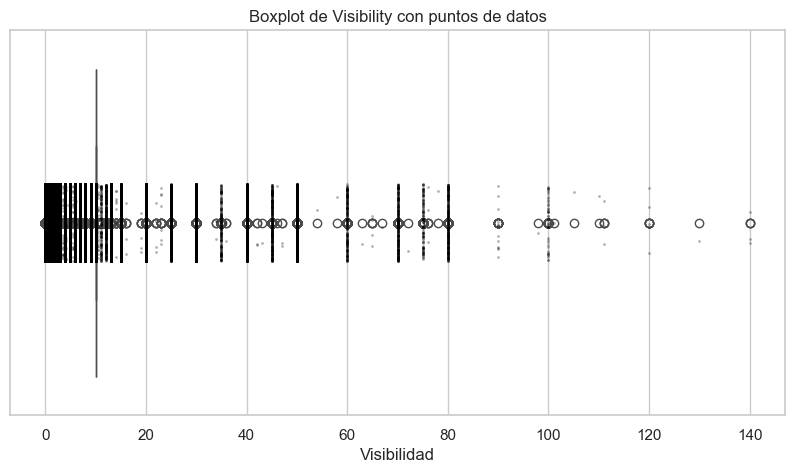


Estadísticas de Visibility:
count    7.551296e+06
mean     9.090376e+00
std      2.688316e+00
min      0.000000e+00
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      1.400000e+02
Name: Visibility(mi), dtype: float64


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# BOXPLOT DE VISIBILITY CON LOS PUNTOS DE LOS DATOS
# ---------------------------------------------------------
# Permite ver la distribución de la visibilidad
# y detectar valores atípicos (outliers)
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

# Boxplot
sns.boxplot(x=df['Visibility(mi)'], showfliers=True)

# Puntos de cada observación
sns.stripplot(x=df['Visibility(mi)'], color="black", size=2, alpha=0.3)

plt.title("Boxplot de Visibility con puntos de datos")
plt.xlabel("Visibilidad")
plt.show()


# ---------------------------------------------------------
# ESTADISTICAS PARA ENTENDER LOS OUTLIERS
# ---------------------------------------------------------
print("\nEstadísticas de Visibility:")
print(df['Visibility(mi)'].describe())

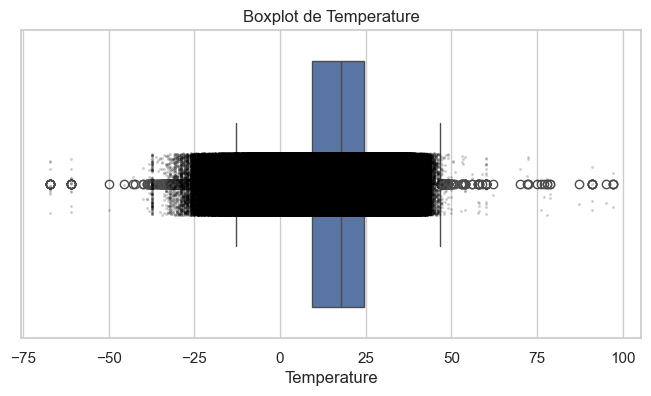

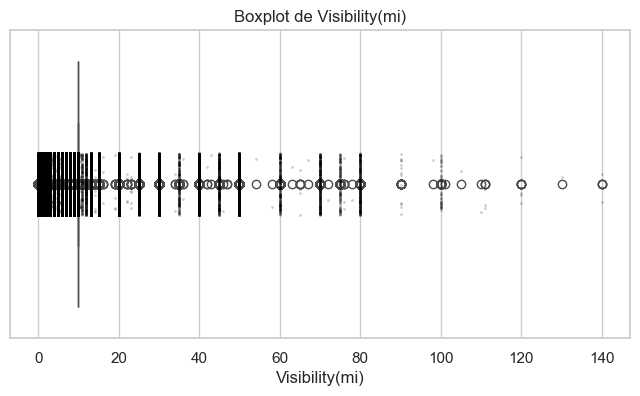

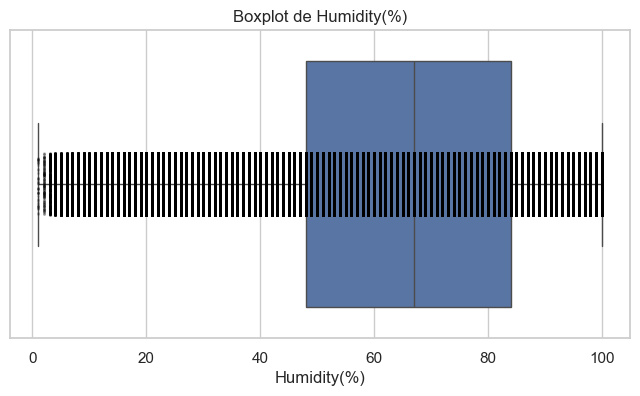

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas = ['Temperature', 'Visibility(mi)', 'Humidity(%)']

for col in columnas:
    
    plt.figure(figsize=(8,4))
    
    # Boxplot
    sns.boxplot(x=df[col], showfliers=True)
    
    # Puntos de cada observación
    sns.stripplot(x=df[col], color="black", size=2, alpha=0.2)
    
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    
    plt.show()

In [44]:
# Guardar tamaño original
##eliminar valores ouliers y nulos
shape_inicial = df.shape[0]

df = df[
    (df['Temperature'].between(-50, 60)) &
    (df['Visibility(mi)'].between(0, 20)) &
    (df['Humidity(%)'].between(0, 100))
]

shape_final = df.shape[0]

print("Filas eliminadas:", shape_inicial - shape_final)
print("Porcentaje eliminado:", 
      ((shape_inicial - shape_final) / shape_inicial) * 100, "%")

Filas eliminadas: 223261
Porcentaje eliminado: 2.888840812204968 %
